In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
import seaborn as sns
from scipy.stats import ttest_rel

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

palette = {'cmGC': '#c04744', 'ncmGC': "#cfb406", 'NGS': '#3171ae', 'GC': '#c04744'}


In [2]:
data_path = '/Users/harryclark/Downloads/COHORT12/xgboost/xgboost_results.csv'
if os.path.exists(data_path):
    # save data somewhere and load it in future sessions
    data = pd.read_csv(data_path)
else:  
    path = '/Users/harryclark/Downloads/COHORT12/xgboost'
 
    data = pd.DataFrame()
    for i, file in enumerate(os.listdir(path)):
        print(f'Reading {file}, {i+1}/{len(os.listdir(path))}')
        file_path = os.path.join(path, file)
        if file.endswith('.pkl'):
            df = pd.read_pickle(file_path)
        elif file.endswith('.csv'):
            df = pd.read_csv(file_path)
        data = pd.concat([data, df], ignore_index=True)
    data.to_csv(data_path, index=False)


In [3]:
# subset dataframe to look at random order_by and session-wide pR2 
random_data = data[(data['ordering'] == 'random') &
            (data['trial_type'] == 'session') &
            (data['trial_context'] == 'session') &
            (data['trial_performance'] == 'session') &
            (data['tested_on'] != 'other')]

In [4]:
def subset_by_n_neurons(df, trained_on='GC', n_neurons=5):
    """
    Subset the dataframe to only include rows with a mouse_day_cluster_id rows which are from sessions with sufficient number of neurons.
    Args:
        df (pd.DataFrame): The input dataframe containing neuron data.
        trained_on (str): The type of neurons to filter on, e.g., 'GC' for grid cells. or 'NGS' for non-grid cells.
        n_neurons (int): The number of neurons to filter by.
    Returns:
        pd.DataFrame: A filtered dataframe
    """
    df = df[df['trained_on'] == trained_on]
    df['mouse_day_cluster_id'] = df['mouse'].astype(str) + '_' + df['day'].astype(str) + '_' + df['cluster_id'].astype(str)
    mouse_day_cluster_id_with_enough_neurons = df[df['n_neurons'] >= n_neurons]['mouse_day_cluster_id'].unique()
    df = df[df['mouse_day_cluster_id'].isin(mouse_day_cluster_id_with_enough_neurons)]
    return df[df['n_neurons'] <= n_neurons]

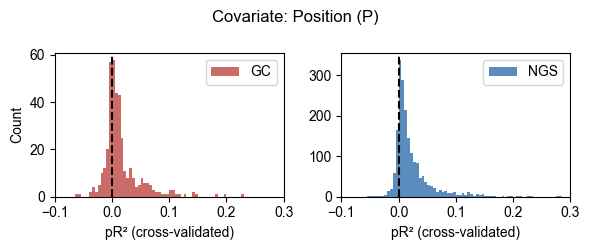

In [30]:
# Subset random_data so there is only one row per mouse+day+cluster_id
random_data_unique = (
    random_data
    .drop_duplicates(subset=["mouse", "day", "cluster_id"])
    .reset_index(drop=True)
)

import matplotlib.pyplot as plt

# Subset into GC and NGS based on tested_on column
gc_labels = ['ncmGC', 'GC', 'cmGC']
gc_data = random_data_unique[random_data_unique['tested_on'].isin(gc_labels)]
ngs_data = random_data_unique[random_data_unique['tested_on'] == 'NGS']

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))

# GC histogram (left)
axes[0].hist(gc_data['pR2'], bins=80, range=[-0.1, 0.3], alpha=0.8, color='#c04744', label='GC')
axes[0].set_xlabel('pR² (cross-validated)')
axes[0].set_ylabel('Count')
axes[0].axvline(x=0, color='k', linestyle='--')
axes[0].set_xlim([-0.1, 0.3])
axes[0].legend()

# NGS histogram (right)
axes[1].hist(ngs_data['pR2'], bins=80, range=[-0.1, 0.3], alpha=0.8, color='#3171ae', label='NGS')
axes[1].set_xlabel('pR² (cross-validated)')
axes[1].axvline(x=0, color='k', linestyle='--')
axes[1].set_xlim([-0.1, 0.3])
axes[1].legend()
plt.suptitle('Covariate: Position (P)')
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/Position_covariate.pdf', dpi=300)
plt.show()

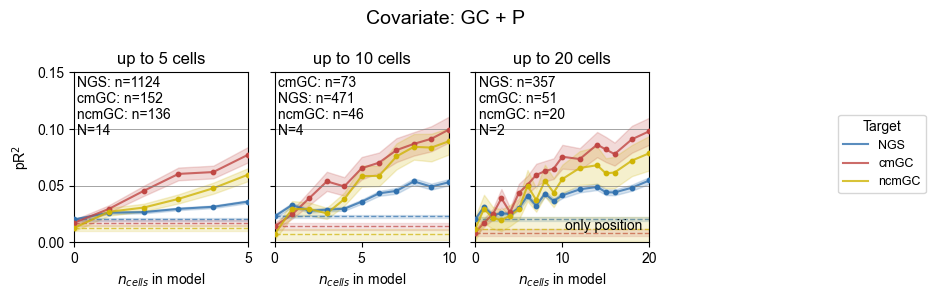

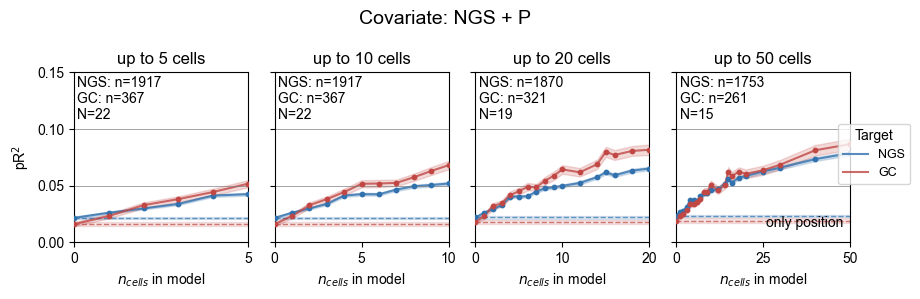

In [19]:
import matplotlib.pyplot as plt
figsize = (9, 3)
palette = {'cmGC': '#c04744', 'ncmGC': "#cfb406", 'NGS': '#3171ae', 'GC': '#c04744'}

# GC: 4 subplots for 5, 10, 20, (blank)
gc_ncells = [5, 10, 20]
fig_gc, axes_gc = plt.subplots(1, 4, figsize=figsize, sharey=True)
for i in range(4):
    if i < len(gc_ncells):
        max_n = gc_ncells[i]
        ax = axes_gc[i]
        trained_on = 'GC'
        valid_data = subset_by_n_neurons(random_data, n_neurons=max_n, trained_on=trained_on)
        if valid_data.empty:
            ax.axis('off')
            continue
        annotation_lines = []
        y0_list = []
        for tested_on in valid_data['tested_on'].unique():
            df_plot = valid_data[(valid_data['trained_on'] == trained_on) & (valid_data['tested_on'] == tested_on)]
            if df_plot.empty:
                continue
            pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
            pivot = pivot.sort_index(axis=1)
            mean = pivot.mean(axis=0)
            sem = pivot.sem(axis=0)
            color = palette.get(tested_on, None)
            mean = mean[mean.index <= max_n]
            sem = sem[sem.index <= max_n]
            ax.plot(mean.index, mean.values, label=f'{tested_on}', alpha=0.8, color=color)
            ax.scatter(mean.index, mean.values, s=10, color=color, zorder=3)
            ax.fill_between(mean.index, mean - sem, mean + sem, alpha=0.2, color=color)
            # Dashed line and fill_between for n=0
            if 0 in pivot.columns:
                y0 = mean.loc[0]
                y0_list.append(y0)
                y0_sem = sem.loc[0]
                ax.axhline(y0, linestyle='dashed', color=color, linewidth=1, alpha=0.7)
                # Fill between y0 ± sem for n=0
                ax.fill_between(
                    [0, max_n],
                    y0 - y0_sem,
                    y0 + y0_sem,
                    color=color,
                    alpha=0.15,
                    zorder=2
                )
            n_test_cells = len(df_plot[df_plot['n_neurons'] == 1])
            annotation_lines.append(f'{tested_on}: n={n_test_cells}')
        n_sessions = valid_data[['mouse', 'day']].drop_duplicates().shape[0]
        annotation_lines.append(f'N={n_sessions}')
        if annotation_lines:
            ax.text(0.02, 0.98, '\n'.join(annotation_lines), ha='left', va='top', transform=ax.transAxes, fontsize=10, color='k', bbox=None)
        ax.axhline(0.05, linestyle='solid', color='grey', linewidth=0.5)
        ax.axhline(0.1, linestyle='solid', color='grey', linewidth=0.5)
        ax.axhline(0.15, linestyle='solid', color='grey', linewidth=0.5)
        ax.set_xlim(0, max_n)
        ax.set_ylim(0, 0.15)
        if i == 0:
            ax.set_xticks([0, 5])
        else:
            ax.set_xticks([0, max_n//2, max_n])
        ax.set_yticks([0, 0.05, 0.1, 0.15])
        ax.set_xlabel('$n_{cells}$ in model')
        if i == 0:
            ax.set_ylabel('pR$^2$')
        ax.set_title(f'up to {max_n} cells')
        # Add 'only position' annotation above the highest dashed n=0 line, anchored right, slightly lower, only on 3rd column
        if i == 2 and y0_list:
            y0_max = max(y0_list)
            ax.annotate(
                'only position',
                xy=(max_n, y0_max), xycoords='data',
                xytext=(-5, -10), textcoords='offset points',
                ha='right', va='bottom',
                fontsize=10, color='k'
            )
    else:
        axes_gc[i].axis('off')
handles, labels = axes_gc[-2].get_legend_handles_labels()
fig_gc.legend(handles, labels, title='Target', fontsize=9, loc='center left', bbox_to_anchor=(0.93, 0.5))
fig_gc.suptitle('Covariate: GC + P', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(hspace=0.6, right=0.95)
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_gc_4col.pdf', bbox_inches='tight')
plt.show()

# NGS: 4 subplots for 5, 10, 20, 50
ngs_ncells = [5, 10, 20, 50]
fig_ngs, axes_ngs = plt.subplots(1, 4, figsize=figsize, sharey=True)
for i, max_n in enumerate(ngs_ncells):
    ax = axes_ngs[i]
    trained_on = 'NGS'
    valid_data = subset_by_n_neurons(random_data, n_neurons=max_n, trained_on=trained_on)
    if valid_data.empty:
        ax.axis('off')
        continue
    annotation_lines = []
    y0_list = []
    for tested_on in valid_data['tested_on'].unique():
        df_plot = valid_data[(valid_data['trained_on'] == trained_on) & (valid_data['tested_on'] == tested_on)]
        if df_plot.empty:
            continue
        pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
        pivot = pivot.sort_index(axis=1)
        mean = pivot.mean(axis=0)
        sem = pivot.sem(axis=0)
        color = palette.get(tested_on, None)
        mean = mean[mean.index <= max_n]
        sem = sem[sem.index <= max_n]
        ax.plot(mean.index, mean.values, label=f'{tested_on}', alpha=0.8, color=color)
        ax.scatter(mean.index, mean.values, s=10, color=color, zorder=3)
        ax.fill_between(mean.index, mean - sem, mean + sem, alpha=0.2, color=color)
        # Dashed line and fill_between for n=0
        if 0 in pivot.columns:
            y0 = mean.loc[0]
            y0_list.append(y0)
            y0_sem = sem.loc[0]
            ax.axhline(y0, linestyle='dashed', color=color, linewidth=1, alpha=0.7)
            # Fill between y0 ± sem for n=0
            ax.fill_between(
                [0, max_n],
                y0 - y0_sem,
                y0 + y0_sem,
                color=color,
                alpha=0.15,
                zorder=2
            )
        n_test_cells = len(df_plot[df_plot['n_neurons'] == 1])
        annotation_lines.append(f'{tested_on}: n={n_test_cells}')
    n_sessions = valid_data[['mouse', 'day']].drop_duplicates().shape[0]
    annotation_lines.append(f'N={n_sessions}')
    if annotation_lines:
        ax.text(0.02, 0.98, '\n'.join(annotation_lines), ha='left', va='top', transform=ax.transAxes, fontsize=10, color='k', bbox=None)
    ax.axhline(0.05, linestyle='solid', color='grey', linewidth=0.5)
    ax.axhline(0.1, linestyle='solid', color='grey', linewidth=0.5)
    ax.axhline(0.15, linestyle='solid', color='grey', linewidth=0.5)
    ax.set_xlim(0, max_n)
    ax.set_ylim(0, 0.15)
    if i == 0:
        ax.set_xticks([0, 5])
    else:
        ax.set_xticks([0, max_n//2, max_n])
    ax.set_yticks([0, 0.05, 0.1, 0.15])
    ax.set_xlabel('$n_{cells}$ in model')
    if i == 0:
        ax.set_ylabel('pR$^2$')
    ax.set_title(f'up to {max_n} cells')
    # Add 'only position' annotation above the highest dashed n=0 line, anchored right, slightly lower, only on 4th column
    if i == 3 and y0_list:
        y0_max = max(y0_list)
        ax.annotate(
            'only position',
            xy=(max_n, y0_max), xycoords='data',
            xytext=(-5, -10), textcoords='offset points',
            ha='right', va='bottom',
            fontsize=10, color='k'
        )
handles, labels = axes_ngs[-1].get_legend_handles_labels()
fig_ngs.legend(handles, labels, title='Target', fontsize=9, loc='center left', bbox_to_anchor=(0.93, 0.5))
fig_ngs.suptitle('Covariate: NGS + P', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(hspace=0.6, right=0.95)
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_ngs_4col.pdf', bbox_inches='tight')
plt.show()

In [ ]:
import statsmodels.formula.api as smf
for trained_on in ['GC', 'NGS']:
    trained_on_data = random_data[random_data['trained_on'] == trained_on]
    trained_on_data['mouse_day'] = trained_on_data['mouse'].astype(str) + "_" + trained_on_data['day'].astype(str)

    model = smf.mixedlm("pR2 ~ tested_on * n_neurons", trained_on_data, groups="mouse", re_formula="~1", vc_formula={"day": "0 + C(day)"})
    result = model.fit()
    print(f"Results for trained_on {trained_on}:")
    print(result.summary())

Results for trained_on GC:
                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        pR2       
No. Observations:        21073          Method:                    REML      
No. Groups:              7              Scale:                     0.0022    
Min. group size:         203            Log-Likelihood:            34219.1986
Max. group size:         6848           Converged:                 Yes       
Mean group size:         3010.4                                              
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.027    0.008  3.553 0.000  0.012  0.042
tested_on[T.cmGC]                  -0.009    0.004 -2.451 0.014 -0.016 -0.002
tested_on[T.ncmGC]                 -0.015    0.004 -4.273

to compare pR2 across tested_on cell_types, we can cycle though the tested_on groups, making each one the reference group from which to compare the other groups against.

In [7]:
import statsmodels.formula.api as smf
import pandas as pd

data_to_use = random_data[random_data['trained_on'] == 'GC'].copy()
tested_on_groups = data_to_use['tested_on'].unique()

results = []

for ref in tested_on_groups:
    # Set reference group
    data_to_use['tested_on'] = pd.Categorical(
        data_to_use['tested_on'],
        categories=[ref] + [g for g in tested_on_groups if g != ref],
        ordered=True
    )
    model = smf.mixedlm("pR2 ~ tested_on * n_neurons", data_to_use, groups="mouse", re_formula="~1", vc_formula={"day": "0 + C(day)"})
    result = model.fit()
    # Extract coefficients, standard errors, and p-values
    params = result.params
    conf_int = result.conf_int()
    pvalues = result.pvalues
    summary_df = pd.DataFrame({
        'coef': params,
        'ci_lower': conf_int[0],
        'ci_upper': conf_int[1],
        'pval': pvalues,
        'reference': ref
    })
    results.append(summary_df.reset_index().rename(columns={'index': 'term'}))

all_results = pd.concat(results, ignore_index=True)
display(all_results)

,term,coef,ci_lower,ci_upper,pval,reference
0,Intercept,0.026788,0.012012,0.041565,0.000381,NGS
1,tested_on[T.cmGC],-0.009000,-0.016197,-0.001804,0.014238,NGS
2,tested_on[T.ncmGC],-0.015021,-0.021912,-0.008130,0.000019,NGS
3,n_neurons[T.1],0.005046,0.002066,0.008026,0.000904,NGS
4,n_neurons[T.2],0.006981,0.004001,0.009961,0.000004,NGS
...,...,...,...,...,...,...
163,tested_on[T.cmGC]:n_neurons[T.20],0.012761,-0.013358,0.038881,0.338262,ncmGC
164,tested_on[T.NGS]:n_neurons[T.25],-0.042768,-0.065067,-0.020470,0.000170,ncmGC
165,tested_on[T.cmGC]:n_neurons[T.25],0.014990,-0.011129,0.041109,0.260665,ncmGC
166,mouse Var,0.112710,-0.100508,0.325927,0.300172,ncmGC


In [8]:
# After running your model loop and creating all_results

# Filter for main effect of tested_on (at n_neurons=0) and interaction terms
main_effects = all_results[all_results['term'].str.startswith('tested_on[')]
interactions = all_results[all_results['term'].str.startswith('tested_on[') & all_results['term'].str.contains(':n_neurons')]

# Clean up term names for clarity
main_effects = main_effects.copy()
main_effects['compared_to'] = main_effects['term'].str.extract(r"tested_on\[(.+?)\]")
main_effects['effect_type'] = 'main'

interactions = interactions.copy()
interactions['compared_to'] = interactions['term'].str.extract(r"tested_on\[(.+?)\]:n_neurons")
interactions['effect_type'] = 'interaction'

# Combine and sort
summary = pd.concat([main_effects, interactions], ignore_index=True)
summary = summary[['reference', 'compared_to', 'effect_type', 'coef', 'ci_lower', 'ci_upper', 'pval']]
summary = summary.sort_values(['reference', 'effect_type', 'compared_to'])

display(summary)

,reference,compared_to,effect_type,coef,ci_lower,ci_upper,pval
108,NGS,T.cmGC,interaction,0.008020,-0.002100,0.018140,1.203664e-01
110,NGS,T.cmGC,interaction,0.022811,0.012691,0.032931,9.968038e-06
112,NGS,T.cmGC,interaction,0.033016,0.022845,0.043187,1.986010e-10
114,NGS,T.cmGC,interaction,0.030832,0.020441,0.041224,6.044357e-09
116,NGS,T.cmGC,interaction,0.041449,0.030722,0.052177,3.649048e-14
...,...,...,...,...,...,...,...
99,ncmGC,T.cmGC,main,0.014433,-0.011686,0.040552,2.787992e-01
101,ncmGC,T.cmGC,main,0.009628,-0.016491,0.035747,4.700001e-01
103,ncmGC,T.cmGC,main,0.012148,-0.013971,0.038267,3.619958e-01
105,ncmGC,T.cmGC,main,0.012761,-0.013358,0.038881,3.382624e-01


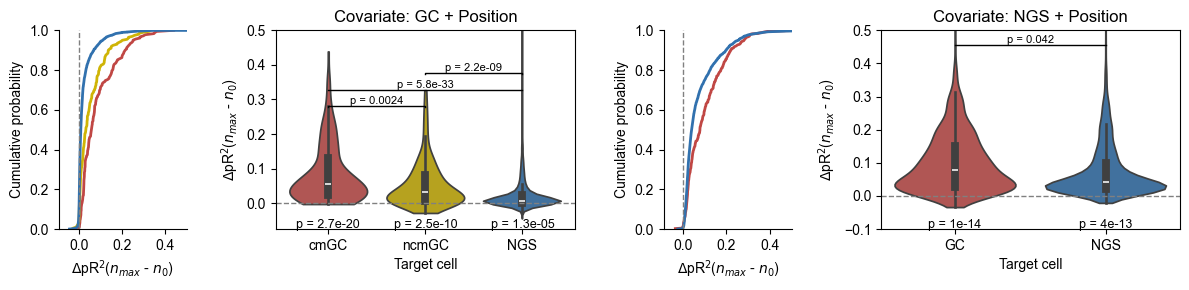

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd

# --- GC analysis (max n_neurons) ---
added_pR2_gc_max = []
for tested_on in ['cmGC', 'ncmGC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'GC') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].notna())
    ].copy()
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    valid_rows = pivot.dropna(subset=[0])
    diffs = []
    for idx, row in valid_rows.iterrows():
        nonzero_cols = [col for col in row.index if col != 0 and not pd.isna(row[col])]
        if len(nonzero_cols) == 0:
            continue
        max_n = max(nonzero_cols)
        diff = row[max_n] - row[0]
        diffs.append({'added_pR2': diff, 'tested_on': tested_on, 'mouse': idx[0], 'day': idx[1], 'cluster_id': idx[2], 'max_n_neurons': max_n})
    temp_df = pd.DataFrame(diffs)
    added_pR2_gc_max.append(temp_df)
added_pR2_gc_max = pd.concat(added_pR2_gc_max, ignore_index=True)

# Pairwise LMM p-values for GC (max n_neurons, refit for each comparison)
gc_groups = ['cmGC', 'ncmGC', 'NGS']
vc_gc = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}
pvals_gc = {}
for g1, g2 in [('cmGC', 'ncmGC'), ('cmGC', 'NGS'), ('ncmGC', 'NGS')]:
    temp = added_pR2_gc_max.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_gc[(g1, g2)] = result.pvalues.get(term, np.nan)

# Refit LMM for GC with each group as reference to get test against zero for each group
gc_zero_pvals = {}
for ref in gc_groups:
    temp = added_pR2_gc_max.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in gc_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    gc_zero_pvals[ref] = result.pvalues['Intercept']

# --- NGS analysis (max n_neurons) ---
added_pR2_ngs_max = []
for tested_on in ['GC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'NGS') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].notna())
    ].copy()
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    valid_rows = pivot.dropna(subset=[0])
    diffs = []
    for idx, row in valid_rows.iterrows():
        nonzero_cols = [col for col in row.index if col != 0 and not pd.isna(row[col])]
        if len(nonzero_cols) == 0:
            continue
        max_n = max(nonzero_cols)
        diff = row[max_n] - row[0]
        diffs.append({'added_pR2': diff, 'tested_on': tested_on, 'mouse': idx[0], 'day': idx[1], 'cluster_id': idx[2], 'max_n_neurons': max_n})
    temp_df = pd.DataFrame(diffs)
    added_pR2_ngs_max.append(temp_df)
added_pR2_ngs_max = pd.concat(added_pR2_ngs_max, ignore_index=True)

# Pairwise LMM p-values for NGS (max n_neurons, refit for each comparison)
ngs_groups = ['GC', 'NGS']
vc_ngs = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}
pvals_ngs = {}
for g1, g2 in [('GC', 'NGS')]:
    temp = added_pR2_ngs_max.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_ngs[(g1, g2)] = result.pvalues.get(term, np.nan)

# Refit LMM for NGS with each group as reference to get test against zero for each group
ngs_zero_pvals = {}
for ref in ngs_groups:
    temp = added_pR2_ngs_max.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in ngs_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    ngs_zero_pvals[ref] = result.pvalues['Intercept']

# --- Combined Figure ---
fig, axes = plt.subplots(1, 4, figsize=(12, 3), width_ratios=[0.3, 0.7, 0.3, 0.7])

# GC max CDF
ax_gc_cdf = axes[0]
for group in gc_groups:
    vals = added_pR2_gc_max[added_pR2_gc_max['tested_on'] == group]['added_pR2'].dropna()
    sorted_vals = np.sort(vals)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax_gc_cdf.plot(sorted_vals, cdf, label=group, color=palette[group], lw=2)
ax_gc_cdf.axvline(0, color='gray', linestyle='--', linewidth=1)
ax_gc_cdf.set_xlabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_gc_cdf.set_ylabel('Cumulative probability')
ax_gc_cdf.set_xlim(None, 0.5)
ax_gc_cdf.set_ylim(0, 1)
ax_gc_cdf.spines['top'].set_visible(False)
ax_gc_cdf.spines['right'].set_visible(False)

# GC max Violin
ax_gc_violin = axes[1]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_gc_max,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_gc_violin
)
ax_gc_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_gc_violin.set_ylabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_gc_violin.set_xlabel('Target cell')
ax_gc_violin.set_title('Covariate: GC + Position')
ax_gc_violin.set_ylim(-0.075, 0.5)
y_max = 0.275
y_min = added_pR2_gc_max['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * y_range
for idx, ((g1, g2), pval) in enumerate(pvals_gc.items()):
    x1, x2 = gc_groups.index(g1), gc_groups.index(g2)
    y = y_start + idx * step
    ax_gc_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_gc_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
y_bottom = ax_gc_violin.get_ylim()[0] + 0.03
for i, group in enumerate(gc_groups):
    ax_gc_violin.text(i, y_bottom, f"p = {gc_zero_pvals[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

# NGS max CDF
ax_ngs_cdf = axes[2]
for group in ngs_groups:
    vals = added_pR2_ngs_max[added_pR2_ngs_max['tested_on'] == group]['added_pR2'].dropna()
    sorted_vals = np.sort(vals)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax_ngs_cdf.plot(sorted_vals, cdf, color=palette[group], lw=2)
ax_ngs_cdf.axvline(0, color='gray', linestyle='--', linewidth=1)
ax_ngs_cdf.set_xlabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_ngs_cdf.set_ylabel('Cumulative probability')
ax_ngs_cdf.set_xlim(None, 0.5)
ax_ngs_cdf.set_ylim(0, 1)
ax_ngs_cdf.spines['top'].set_visible(False)
ax_ngs_cdf.spines['right'].set_visible(False)

# NGS max Violin
ax_ngs_violin = axes[3]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_ngs_max,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_ngs_violin
)
ax_ngs_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_ngs_violin.set_ylabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_ngs_violin.set_xlabel('Target cell')
ax_ngs_violin.set_title('Covariate: NGS + Position')
ax_ngs_violin.set_ylim(-0.1, 0.5)
y_max = 0.45
y_min = added_pR2_ngs_max['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * y_range
for idx, ((g1, g2), pval) in enumerate(pvals_ngs.items()):
    x1, x2 = ngs_groups.index(g1), ngs_groups.index(g2)
    y = y_start + idx * step
    ax_ngs_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_ngs_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
y_bottom = ax_ngs_violin.get_ylim()[0] + 0.03
for i, group in enumerate(ngs_groups):
    ax_ngs_violin.text(i, y_bottom, f"p = {ngs_zero_pvals[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_max_gc_ngs_combined_4col_lmm.pdf', bbox_inches='tight')
plt.show()

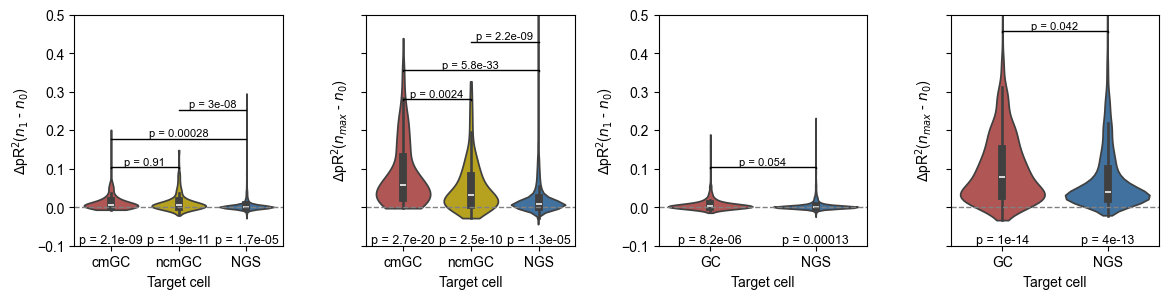

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd

# --- GC analysis ---
added_pR2_gc = []
for tested_on in ['cmGC', 'ncmGC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'GC') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].isin([0, 1]))
    ].copy()
    df_plot['mouse_day_cluster'] = (
        df_plot['mouse'].astype(str) + '_' +
        df_plot['day'].astype(str) + '_' +
        df_plot['cluster_id'].astype(str)
    )
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    pivot = pivot.dropna(subset=[0, 1])
    temp_df = pd.DataFrame({
        'added_pR2': pivot[1] - pivot[0],
        'tested_on': tested_on,
        'mouse': [idx[0] for idx in pivot.index],
        'day': [idx[1] for idx in pivot.index],
        'cluster_id': [idx[2] for idx in pivot.index]
    })
    added_pR2_gc.append(temp_df)
added_pR2_gc = pd.concat(added_pR2_gc, ignore_index=True)

gc_groups = ['cmGC', 'ncmGC', 'NGS']
vc_gc = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}
pvals_gc = {}
for g1, g2 in [('cmGC', 'ncmGC'), ('cmGC', 'NGS'), ('ncmGC', 'NGS')]:
    temp = added_pR2_gc.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_gc[(g1, g2)] = result.pvalues.get(term, np.nan)

gc_zero_pvals = {}
for ref in gc_groups:
    temp = added_pR2_gc.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in gc_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    gc_zero_pvals[ref] = result.pvalues['Intercept']

# --- NGS analysis ---
added_pR2_ngs = []
for tested_on in ['GC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'NGS') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].isin([0, 1]))
    ].copy()
    df_plot['mouse_day_cluster'] = (
        df_plot['mouse'].astype(str) + '_' +
        df_plot['day'].astype(str) + '_' +
        df_plot['cluster_id'].astype(str)
    )
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    pivot = pivot.dropna(subset=[0, 1])
    temp_df = pd.DataFrame({
        'added_pR2': pivot[1] - pivot[0],
        'tested_on': tested_on,
        'mouse': [idx[0] for idx in pivot.index],
        'day': [idx[1] for idx in pivot.index],
        'cluster_id': [idx[2] for idx in pivot.index]
    })
    added_pR2_ngs.append(temp_df)
added_pR2_ngs = pd.concat(added_pR2_ngs, ignore_index=True)

ngs_groups = ['GC', 'NGS']
vc_ngs = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}
pvals_ngs = {}
for g1, g2 in [('GC', 'NGS')]:
    temp = added_pR2_ngs.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_ngs[(g1, g2)] = result.pvalues.get(term, np.nan)

ngs_zero_pvals = {}
for ref in ngs_groups:
    temp = added_pR2_ngs.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in ngs_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    ngs_zero_pvals[ref] = result.pvalues['Intercept']

# --- GC analysis (max n_neurons) ---
added_pR2_gc_max = []
for tested_on in ['cmGC', 'ncmGC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'GC') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].notna())
    ].copy()
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    valid_rows = pivot.dropna(subset=[0])
    diffs = []
    for idx, row in valid_rows.iterrows():
        nonzero_cols = [col for col in row.index if col != 0 and not pd.isna(row[col])]
        if len(nonzero_cols) == 0:
            continue
        max_n = max(nonzero_cols)
        diff = row[max_n] - row[0]
        diffs.append({'added_pR2': diff, 'tested_on': tested_on, 'mouse': idx[0], 'day': idx[1], 'cluster_id': idx[2], 'max_n_neurons': max_n})
    temp_df = pd.DataFrame(diffs)
    added_pR2_gc_max.append(temp_df)
added_pR2_gc_max = pd.concat(added_pR2_gc_max, ignore_index=True)

pvals_gc_max = {}
for g1, g2 in [('cmGC', 'ncmGC'), ('cmGC', 'NGS'), ('ncmGC', 'NGS')]:
    temp = added_pR2_gc_max.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_gc_max[(g1, g2)] = result.pvalues.get(term, np.nan)

gc_zero_pvals_max = {}
for ref in gc_groups:
    temp = added_pR2_gc_max.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in gc_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    gc_zero_pvals_max[ref] = result.pvalues['Intercept']

# --- NGS analysis (max n_neurons) ---
added_pR2_ngs_max = []
for tested_on in ['GC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'NGS') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].notna())
    ].copy()
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    valid_rows = pivot.dropna(subset=[0])
    diffs = []
    for idx, row in valid_rows.iterrows():
        nonzero_cols = [col for col in row.index if col != 0 and not pd.isna(row[col])]
        if len(nonzero_cols) == 0:
            continue
        max_n = max(nonzero_cols)
        diff = row[max_n] - row[0]
        diffs.append({'added_pR2': diff, 'tested_on': tested_on, 'mouse': idx[0], 'day': idx[1], 'cluster_id': idx[2], 'max_n_neurons': max_n})
    temp_df = pd.DataFrame(diffs)
    added_pR2_ngs_max.append(temp_df)
added_pR2_ngs_max = pd.concat(added_pR2_ngs_max, ignore_index=True)

pvals_ngs_max = {}
for g1, g2 in [('GC', 'NGS')]:
    temp = added_pR2_ngs_max.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_ngs_max[(g1, g2)] = result.pvalues.get(term, np.nan)

ngs_zero_pvals_max = {}
for ref in ngs_groups:
    temp = added_pR2_ngs_max.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in ngs_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    ngs_zero_pvals_max[ref] = result.pvalues['Intercept']

# --- Combined Figure (Violin only, 4 columns) ---
fig, axes = plt.subplots(1, 4, figsize=(14, 3), width_ratios=[0.7, 0.7, 0.7, 0.7])

# GC covariate violin (n=1)
ax_gc_violin = axes[0]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_gc,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_gc_violin
)
ax_gc_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_gc_violin.set_ylabel('$\\Delta$pR$^2$($n_{1}$ - $n_{0}$)')
ax_gc_violin.set_xlabel('Target cell')
ax_gc_violin.set_ylim(-0.075, 0.2)
y_max = 0.1
y_min = added_pR2_gc['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * 0.5
for idx, ((g1, g2), pval) in enumerate(pvals_gc.items()):
    x1, x2 = gc_groups.index(g1), gc_groups.index(g2)
    y = y_start + idx * step
    ax_gc_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_gc_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
ax_gc_violin.set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
y_bottom = -0.07
for i, group in enumerate(gc_groups):
    ax_gc_violin.text(i, y_bottom, f"p = {gc_zero_pvals[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

# GC covariate violin (max n)
ax_gc_max_violin = axes[1]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_gc_max,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_gc_max_violin
)
ax_gc_max_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_gc_max_violin.set_ylabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_gc_max_violin.set_xlabel('Target cell')
ax_gc_max_violin.set_ylim(-0.075, 0.5)
y_max = 0.275
y_min = added_pR2_gc_max['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * 0.5
for idx, ((g1, g2), pval) in enumerate(pvals_gc_max.items()):
    x1, x2 = gc_groups.index(g1), gc_groups.index(g2)
    y = y_start + idx * step
    ax_gc_max_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_gc_max_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
ax_gc_max_violin.set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax_gc_max_violin.set_yticklabels(['', '', '', '', '', '', ''])
y_bottom = -0.07
for i, group in enumerate(gc_groups):
    ax_gc_max_violin.text(i, y_bottom, f"p = {gc_zero_pvals_max[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

# NGS covariate violin (n=1)
ax_ngs_violin = axes[2]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_ngs,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_ngs_violin
)
ax_ngs_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_ngs_violin.set_ylabel('$\\Delta$pR$^2$($n_{1}$ - $n_{0}$)')
ax_ngs_violin.set_xlabel('Target cell')
ax_ngs_violin.set_ylim(-0.075, 0.2)
y_max = 0.1
y_min = added_pR2_ngs['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * 0.5
for idx, ((g1, g2), pval) in enumerate(pvals_ngs.items()):
    x1, x2 = ngs_groups.index(g1), ngs_groups.index(g2)
    y = y_start + idx * step
    ax_ngs_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_ngs_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
ax_ngs_violin.set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
y_bottom = -0.07
for i, group in enumerate(ngs_groups):
    ax_ngs_violin.text(i, y_bottom, f"p = {ngs_zero_pvals[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

# NGS covariate violin (max n)
ax_ngs_max_violin = axes[3]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_ngs_max,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_ngs_max_violin
)
ax_ngs_max_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_ngs_max_violin.set_ylabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_ngs_max_violin.set_xlabel('Target cell')
ax_ngs_max_violin.set_ylim(-0.1, 0.5)
y_max = 0.45
y_min = added_pR2_ngs_max['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * 0.5
for idx, ((g1, g2), pval) in enumerate(pvals_ngs_max.items()):
    x1, x2 = ngs_groups.index(g1), ngs_groups.index(g2)
    y = y_start + idx * step
    ax_ngs_max_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_ngs_max_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
ax_ngs_max_violin.set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax_ngs_max_violin.set_yticklabels(['', '', '', '', '', '', ''])
y_bottom = -0.07
for i, group in enumerate(ngs_groups):
    ax_ngs_max_violin.text(i, y_bottom, f"p = {ngs_zero_pvals_max[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

plt.subplots_adjust(wspace=0.4)  # Custom spacing between subplots
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_gc_ngs_violin_only_4col.pdf', bbox_inches='tight')
plt.show()


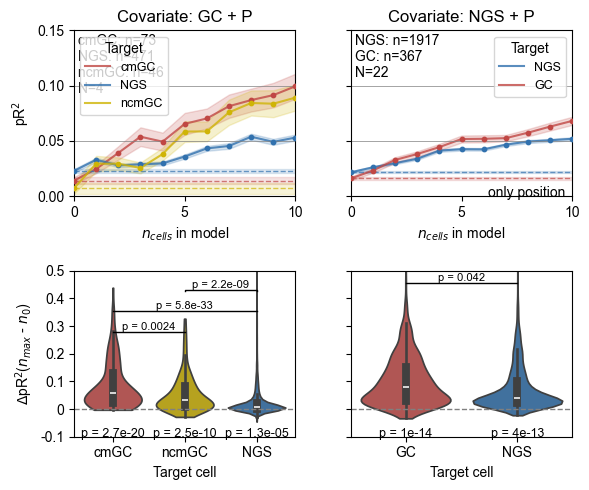

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

max_n = 10
covariates = ['GC', 'NGS']
palette = {'cmGC': '#c04744', 'ncmGC': "#cfb406", 'NGS': '#3171ae', 'GC': '#c04744'}

fig, axes = plt.subplots(2, 2, figsize=(6, 5), sharey='row')  # Slightly less wide

# --- Top row: Line plots ---
# GC line plot
ax_gc_line = axes[0, 0]
trained_on = 'GC'
valid_data = subset_by_n_neurons(random_data, n_neurons=max_n, trained_on=trained_on)
if valid_data.empty:
    ax_gc_line.axis('off')
else:
    annotation_lines = []
    for tested_on in valid_data['tested_on'].unique():
        df_plot = valid_data[(valid_data['trained_on'] == trained_on) & (valid_data['tested_on'] == tested_on)]
        if df_plot.empty:
            continue
        pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
        pivot = pivot.sort_index(axis=1)
        mean = pivot.mean(axis=0)
        sem = pivot.sem(axis=0)
        color = palette.get(tested_on, None)
        mean = mean[mean.index <= max_n]
        sem = sem[sem.index <= max_n]
        ax_gc_line.plot(mean.index, mean.values, label=f'{tested_on}', alpha=0.8, color=color)
        ax_gc_line.scatter(mean.index, mean.values, s=10, color=color, zorder=3)
        ax_gc_line.fill_between(mean.index, mean - sem, mean + sem, alpha=0.2, color=color)
        # Dashed line and fill_between for n=0
        if 0 in pivot.columns:
            y0 = mean.loc[0]
            y0_sem = sem.loc[0]
            ax_gc_line.axhline(y0, linestyle='dashed', color=color, linewidth=1, alpha=0.7)
            # Fill between y0 ± sem for n=0
            ax_gc_line.fill_between(
                [0, max_n],
                y0 - y0_sem,
                y0 + y0_sem,
                color=color,
                alpha=0.15,
                zorder=2
            )
        n_test_cells = len(df_plot[df_plot['n_neurons'] == 1])
        annotation_lines.append(f'{tested_on}: n={n_test_cells}')
    n_sessions = valid_data[['mouse', 'day']].drop_duplicates().shape[0]
    annotation_lines.append(f'N={n_sessions}')
    if annotation_lines:
        ax_gc_line.text(0.02, 0.98, '\n'.join(annotation_lines), ha='left', va='top', transform=ax_gc_line.transAxes, fontsize=10, color='k', bbox=None)
    ax_gc_line.axhline(0.05, linestyle='solid', color='grey', linewidth=0.5)
    ax_gc_line.axhline(0.1, linestyle='solid', color='grey', linewidth=0.5)
    ax_gc_line.axhline(0.15, linestyle='solid', color='grey', linewidth=0.5)
    ax_gc_line.set_xlim(0, max_n)
    ax_gc_line.set_ylim(0, 0.15)
    ax_gc_line.set_xticks([0, 5, 10])
    ax_gc_line.set_yticks([0, 0.05, 0.1, 0.15])
    ax_gc_line.set_xlabel('$n_{cells}$ in model')
    ax_gc_line.set_ylabel('pR$^2$')
    ax_gc_line.set_title('Covariate: GC + P')
    ax_gc_line.legend(title='Target', fontsize=9)

# NGS line plot
ax_ngs_line = axes[0, 1]
trained_on = 'NGS'
valid_data = subset_by_n_neurons(random_data, n_neurons=max_n, trained_on=trained_on)
if valid_data.empty:
    ax_ngs_line.axis('off')
else:
    annotation_lines = []
    y0_list = []
    for tested_on in valid_data['tested_on'].unique():
        df_plot = valid_data[(valid_data['trained_on'] == trained_on) & (valid_data['tested_on'] == tested_on)]
        if df_plot.empty:
            continue
        pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
        pivot = pivot.sort_index(axis=1)
        mean = pivot.mean(axis=0)
        sem = pivot.sem(axis=0)
        color = palette.get(tested_on, None)
        mean = mean[mean.index <= max_n]
        sem = sem[sem.index <= max_n]
        ax_ngs_line.plot(mean.index, mean.values, label=f'{tested_on}', alpha=0.8, color=color)
        ax_ngs_line.scatter(mean.index, mean.values, s=10, color=color, zorder=3)
        ax_ngs_line.fill_between(mean.index, mean - sem, mean + sem, alpha=0.2, color=color)
        # Dashed line and fill_between for n=0
        if 0 in pivot.columns:
            y0 = mean.loc[0]
            y0_sem = sem.loc[0]
            y0_list.append(y0)
            ax_ngs_line.axhline(y0, linestyle='dashed', color=color, linewidth=1, alpha=0.7)
            # Fill between y0 ± sem for n=0
            ax_ngs_line.fill_between(
                [0, max_n],
                y0 - y0_sem,
                y0 + y0_sem,
                color=color,
                alpha=0.15,
                zorder=2
            )
        n_test_cells = len(df_plot[df_plot['n_neurons'] == 1])
        annotation_lines.append(f'{tested_on}: n={n_test_cells}')
    n_sessions = valid_data[['mouse', 'day']].drop_duplicates().shape[0]
    annotation_lines.append(f'N={n_sessions}')
    if annotation_lines:
        ax_ngs_line.text(0.02, 0.98, '\n'.join(annotation_lines), ha='left', va='top', transform=ax_ngs_line.transAxes, fontsize=10, color='k', bbox=None)
    ax_ngs_line.axhline(0.05, linestyle='solid', color='grey', linewidth=0.5)
    ax_ngs_line.axhline(0.1, linestyle='solid', color='grey', linewidth=0.5)
    ax_ngs_line.axhline(0.15, linestyle='solid', color='grey', linewidth=0.5)
    ax_ngs_line.set_xlim(0, max_n)
    ax_ngs_line.set_ylim(0, 0.15)
    ax_ngs_line.set_xticks([0, 5, 10])
    ax_ngs_line.set_yticks([0, 0.05, 0.1, 0.15])
    ax_ngs_line.set_xlabel('$n_{cells}$ in model')
    ax_ngs_line.set_title('Covariate: NGS + P')
    ax_ngs_line.legend(title='Target', fontsize=9)
    # Add 'only position' annotation above the highest dashed n=0 line, anchored right, slightly lower
    if y0_list:
        y0_max = max(y0_list)
        ax_ngs_line.annotate(
            'only position',
            xy=(max_n, y0_max), xycoords='data',
            xytext=(-5, -20), textcoords='offset points',  # moved lower
            ha='right', va='bottom',
            fontsize=10, color='k'
        )

# --- Bottom row: Violin plots ---
# GC violin (max n)
ax_gc_max_violin = axes[1, 0]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_gc_max,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_gc_max_violin
)
ax_gc_max_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_gc_max_violin.set_ylabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_gc_max_violin.set_xlabel('Target cell')
ax_gc_max_violin.set_ylim(-0.075, 0.5)
ax_gc_max_violin.set_title("")
ax_gc_max_violin.set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax_gc_max_violin.set_yticklabels(['-0.1', '0', '0.1', '0.2', '0.3', '0.4', '0.5'])
y_bottom = -0.07
gc_groups = ['cmGC', 'ncmGC', 'NGS']
for i, group in enumerate(gc_groups):
    ax_gc_max_violin.text(i, y_bottom, f"p = {gc_zero_pvals_max[group]:.2g}", ha='center', va='top', fontsize=9, color='black')
# Add pairwise p-values above violins
y_max = 0.275
y_min = added_pR2_gc_max['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * 0.5
for idx, ((g1, g2), pval) in enumerate(pvals_gc_max.items()):
    x1, x2 = gc_groups.index(g1), gc_groups.index(g2)
    y = y_start + idx * step
    ax_gc_max_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_gc_max_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)

# NGS violin (max n)
ax_ngs_max_violin = axes[1, 1]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_ngs_max,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_ngs_max_violin
)
ax_ngs_max_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_ngs_max_violin.set_ylabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_ngs_max_violin.set_xlabel('Target cell')
ax_ngs_max_violin.set_ylim(-0.1, 0.5)
ax_ngs_max_violin.set_title("")
ax_ngs_max_violin.set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax_ngs_max_violin.set_yticklabels(['-0.1', '0', '0.1', '0.2', '0.3', '0.4', '0.5'])
y_bottom = -0.07
ngs_groups = ['GC', 'NGS']
for i, group in enumerate(ngs_groups):
    ax_ngs_max_violin.text(i, y_bottom, f"p = {ngs_zero_pvals_max[group]:.2g}", ha='center', va='top', fontsize=9, color='black')
# Add pairwise p-values above violins
y_max = 0.45
y_min = added_pR2_ngs_max['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * 0.5
for idx, ((g1, g2), pval) in enumerate(pvals_ngs_max.items()):
    x1, x2 = ngs_groups.index(g1), ngs_groups.index(g2)
    y = y_start + idx * step
    ax_ngs_max_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_ngs_max_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.25, hspace=0.45)
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_gc_ngs_combined_line_violin_grid.pdf', bbox_inches='tight')
plt.show()